In [1]:
import pandas as pd
import numpy as np
import gurobipy as gp
import random
from tqdm import tqdm

In [2]:
travel_times_15_17 = pd.read_csv("travel_times_15_17.csv", index_col=0)
travel_times_17_19 = pd.read_csv("travel_times_17_19.csv", index_col=0)
travel_times_19_21 = pd.read_csv("travel_times_19_21.csv", index_col=0)

travel_times = pd.concat([travel_times_15_17, travel_times_17_19, travel_times_19_21], ignore_index=False)

travel_times.index.name = "departure_time"

travel_times.reset_index(inplace=True)


travel_times['departure_time'] = pd.to_datetime(travel_times['departure_time'])

stations = list(set(travel_times['origin_station_id'].unique()) | set(travel_times['dest_station_id'].unique()))

#avg_travel_times = travel_times.groupby(['origin_station_id', 'dest_station_id'])['duration_in_traffic_minutes'].mean().to_dict()

#def get_travel_time(orig, dest):
#    if orig == 0 or dest == 0: return 0.0 # Virtual destination '0' takes 0 mins to reach
#    if orig == dest: return 0.0
#    # Fallback to 10 mins if a specific OD pair happens to be missing in the CSV
#    return avg_travel_times.get((orig, dest), 10.0)

In [3]:
travel_times.head()

,departure_time,origin_station_id,origin_name,origin_lat,origin_lon,dest_station_id,dest_name,dest_lat,dest_lon,distance_meters,duration_seconds,duration_minutes,duration_in_traffic_seconds,duration_in_traffic_minutes,status
0,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589152,"Fribourg, Mon-Repos",46.806711,7.172136,270,35,0.58,42,0.70,OK
1,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589138,"Fribourg, Cité-Jardins",46.809385,7.170446,659,86,1.43,117,1.95,OK
2,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8591766,"Fribourg, Boschung",46.811451,7.171016,1013,138,2.30,174,2.90,OK
3,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8587255,"Fribourg, Tilleul/Cathédrale",46.806090,7.161261,3788,445,7.42,506,8.43,OK
4,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589161,"Fribourg, St-Pierre",46.803911,7.155266,4335,561,9.35,622,10.37,OK


In [4]:
t_start = 0
t_end = 50
interval = 10 # Changed to 10 minutes
time_stamps = range(t_start, t_end + 1, interval)

M = 4000
w = 1 
w_max = 30 
b_1 = 1
b_2 = 1
b_3 = 1
c_0 = 1000
a_max = 2 
pax_max_wait = 15

In [5]:
travel_times = travel_times.sort_values('departure_time')

# Convert timestamps into relative minutes (where 15:00 is t=0)
start_time = travel_times['departure_time'].min()
travel_times['t_minutes'] = (travel_times['departure_time'] - start_time).dt.total_seconds() // 60

# 3. Pivot so that rows are time intervals and columns are (origin, dest) pairs
tt_pivot = travel_times.pivot_table(
    index='t_minutes',
    columns=['origin_station_id', 'dest_station_id'],
    values='duration_in_traffic_minutes',
    aggfunc='mean'
)

# 4. Reindex to your simulation timestamps (0, 10, 20... 720) and Forward Fill!
# .bfill() catches any weird gaps at the very beginning, just in case.
tt_filled = tt_pivot.reindex(time_stamps).ffill().bfill()

# 5. Handle any completely missing OD pairs by filling them with a default (e.g., 10 mins)
tt_filled = tt_filled.fillna(10.0)

# 6. Convert to a highly optimized dictionary keyed by (t, orig, dest)
# This prevents pandas lookups inside the Gurobi loop, which are slow.
time_aware_travel_dict = tt_filled.stack([0, 1]).to_dict()

def get_travel_time(orig, dest, current_t):
    if orig == 0 or dest == 0: return 0.0 # Virtual nodes take 0 mins
    if orig == dest: return 0.0
    
    # Query the new dictionary using the current time step
    return time_aware_travel_dict.get((current_t, orig, dest), 10.0)

In [6]:
# Map the capacities to their respective costs
cost_mapping = {6: 40, 8: 30, 10: 20}

# Create 8 buses with a random capacity of 6, 8, or 10, and a random starting station
K = [[random.choice([6, 8, 10]), random.choice(stations), 0] for _ in range(5)]

# Set up the indices
bus_idx = list(range(len(K)))

# Build the cost dictionary by looking at the capacity (index 0) of each bus in K
bus_cost = {k: cost_mapping[K[k][0]] for k in bus_idx}

In [7]:
num_initial_requests = np.random.poisson(10)
R_wait = []
req_t_p_wait = []

In [8]:
for _ in range(num_initial_requests):
    pax = random.randint(1, 3)
    orig = random.choice(stations)
    dest = random.choice(stations)
    while dest == orig:
        dest = random.choice(stations)
    
    R_wait.append([pax, orig, dest])
    req_t_p_wait.append(random.randint(0, interval))

R_sched = []
req_t_p_sched = []

R = R_wait + R_sched
req_t_p = req_t_p_wait + req_t_p_sched
n_req = len(R)
u_dict = {}

history_routes = {k: [] for k in bus_idx}
history_stats = {
    'time_step': [], 'new_reqs_presented': [], 'reqs_rejected': [],
    'obj_cost': [], 'in_transit_carried_over': []
}

In [9]:
history_routes = {k: [] for k in bus_idx}
history_stats = {
    'time_step': [],
    'new_reqs_presented': [],
    'reqs_rejected': [],
    'obj_cost': [],
    'in_transit_carried_over': []
}

In [10]:
def my_callback(model, where):
    if where == gp.GRB.Callback.MIPSOL:
        # This triggers only when a new BEST integer solution is found
        obj = model.cbGet(gp.GRB.Callback.MIPSOL_OBJ)
        bound = model.cbGet(gp.GRB.Callback.MIPSOL_OBJBND)
        tqdm.write(f"   → New Best Obj: {obj:.2f} (Bound: {bound:.2f})")

In [ ]:
for t in tqdm(time_stamps, desc="Simulation Progress", unit="interval"):
    #print(f"\nStarting iteration for time {t} minutes")

    # Step 1: Creating unique node indices for each requested pickup (also separated into wait and sched)
    P_nodes = list(range(n_req))
    P_wait = list(range(len(R_wait)))
    P_sched = list(range(len(R_wait), len(R_wait) + len(R_sched)))

    # Step 2: Creating unique node indices for each requested dropoff
    D_nodes = list(range(n_req, 2*n_req))

    # Step 3: Creating unique node indices for each vehicle initial position and virtual destination
    S_nodes = list(range(2*n_req, 2*n_req + len(K)))
    Z_nodes = list(range(2*n_req + len(K), 2*n_req + 2*len(K)))

    # Step 4: Creating node sets
    P_and_D = P_nodes + D_nodes
    N = P_nodes + D_nodes + S_nodes + Z_nodes

    # Step 5: Creating mapping from modeling nodes to physical nodes
    P_loc = {i: R[i][1] for i in range(n_req)}
    D_loc = {i+n_req: R[i][2] for i in range(n_req)}
    S_loc = {S_nodes[k]: K[k][1] for k in range(len(K))}
    Z_loc = {Z_nodes[k]: K[k][2] for k in range(len(K))}

    node_to_loc = {}
    node_to_loc.update(P_loc)
    node_to_loc.update(D_loc)
    node_to_loc.update(S_loc)
    node_to_loc.update(Z_loc)

    # Create dictionary travel times keyed by logical nodes
    t_dict = {(i,j): get_travel_time(node_to_loc[i], node_to_loc[j], t) for i in N for j in N}

    # Fixed code (assuming 1 minute boarding time):
    s_dict = {i: 1 if i in P_nodes + D_nodes else 0 for i in N}

    # Remove ghost boarding times for passengers already on the bus
    for idx, i in enumerate(P_sched):
        if req_t_p_sched[idx] <= t: # This identifies in-transit passengers
            s_dict[i] = 0

    tep = {} 
    tlp = {} 
    ted = {} 
    tld = {} 

    for idx, i in enumerate(P_nodes):
        tep[i] = req_t_p[idx]
        tlp[i] = tep[i] + pax_max_wait

    for idx, i in enumerate(D_nodes):
        pickup_node = i - n_req 
        travel_time = t_dict[pickup_node, i]
        ted[i] = 0 # We'll assume no constraint on earliest drop-off time in a first step
        tld[i] = tep[pickup_node] + max(travel_time * a_max, pax_max_wait + s_dict[pickup_node])

    e_dict = {}
    l_dict = {}

    for i in P_nodes:
        e_dict[i] = tep[i]
        l_dict[i] = tlp[i]

    for i in D_nodes:
        e_dict[i] = ted[i]
        l_dict[i] = tld[i]

    for i in S_nodes + Z_nodes:
        e_dict[i] = 0
        l_dict[i] = 1440 # 1 full day in minutes

    # Step 6: extract capacities from requests
    Q = {}

    for i in P_nodes:
        Q[i] = R[i][0]

    for i in D_nodes:
        Q[i] = -R[i-n_req][0]

    for i in S_nodes + Z_nodes:
        Q[i] = 0
        
    Q_max = [vehicle[0] for vehicle in K]

    ub_dict = {(i, k): Q_max[k] for i in N for k in bus_idx}

    # Step 7: Create A_m matrix mapping logical nodes to physical stations
    M_stations = list(set(node_to_loc.values()))

    A_m = {}

    # i is the logical node, m is the physical station
    for i in P_and_D:
        for m in M_stations:
            if node_to_loc[i] == m:
                A_m[i, m] = 1
            else:
                A_m[i, m] = 0

    # Step 8: Building model
    # Initializing the model
    model_MILP_base = gp.Model("MILP_base")
    model_MILP_base.Params.OutputFlag = 0

    # Stop if the best solution is within 5% of the theoretical best
    #model_MILP_base.Params.MIPGap = 0.05 
    
    # Stop after 60 seconds no matter what, and take the best found so far
    model_MILP_base.Params.TimeLimit = 240

    # Initializing the decision variables
    x_base = model_MILP_base.addVars(N, N, bus_idx, vtype=gp.GRB.BINARY, name="x")
    q_k = model_MILP_base.addVars(N, bus_idx, vtype=gp.GRB.INTEGER, lb=0, ub=ub_dict, name="q_k")
    w_k = model_MILP_base.addVars(N, bus_idx, vtype=gp.GRB.CONTINUOUS, lb=0, ub=w_max, name="w_k")
    a_k = model_MILP_base.addVars(N, bus_idx, vtype=gp.GRB.CONTINUOUS, name="a_k")
    mu = model_MILP_base.addVars(N, bus_idx, vtype=gp.GRB.CONTINUOUS, lb=1, ub=len(N), name="mu")
    y = model_MILP_base.addVars(P_nodes, vtype=gp.GRB.BINARY, name="y")

    # Objective funtion to be minimized
    obj_expr_trav_cost = gp.quicksum(
        b_1 * bus_cost[k] * t_dict[i, j] * x_base[i, j, k]
        for i in N
        for j in N
        for k in bus_idx
    )

    for i in P_nodes:
        model_MILP_base.addConstr(
            gp.quicksum(x_base[i, j, k] for j in P_and_D for k in bus_idx) == y[i]
        )

    obj_expr_reject_cost = gp.quicksum(
        b_2 * c_0 * (1 - y[i]) for i in P_nodes
    )

    # obj_expr_recourse_cost = b_3 * E

    # Late arrival slack (minutes)
    late_slack = model_MILP_base.addVars(N, bus_idx, vtype=gp.GRB.CONTINUOUS, lb=0, name="late_slack")
    # Add to your setObjective call:
    obj_late_penalty = gp.quicksum(10000 * late_slack[i, k] for i in N for k in bus_idx)

    model_MILP_base.setObjective(obj_expr_trav_cost + obj_expr_reject_cost + obj_late_penalty, gp.GRB.MINIMIZE)

    # Constraints

    # Previous scheduled request served
    for i in P_sched:
        for k in bus_idx:
            model_MILP_base.addConstr(
                gp.quicksum(x_base[i, j, k] for j in N) == u_dict[k, i]
            )

    # Each request served at most once
    for i in P_wait:
        model_MILP_base.addConstr(
            gp.quicksum(x_base[i, j, k] for j in N for k in bus_idx) <= 1
        )

    # Ensures same vehicle visits pickup and drop-off nodes of same request
    for i in P_nodes:
        d = i + n_req
        for k in bus_idx:
            model_MILP_base.addConstr(
                gp.quicksum(x_base[i, j, k] for j in N) 
                - gp.quicksum(x_base[d, j, k] for j in N) == 0
            )

    # Flow conservation constraints
    for i in P_nodes + D_nodes:
        for k in bus_idx:
            model_MILP_base.addConstr(
                gp.quicksum(x_base[i, j, k] for j in N) 
                - gp.quicksum(x_base[j, i, k] for j in N) == 0
            )

    for k in bus_idx:
        model_MILP_base.addConstr(
            gp.quicksum(x_base[S_nodes[k], j, k] for j in N) 
            - gp.quicksum(x_base[j, S_nodes[k], k] for j in N) == 1
        )

    for k in bus_idx:
        model_MILP_base.addConstr(
            gp.quicksum(x_base[Z_nodes[k], j, k] for j in N) 
            - gp.quicksum(x_base[j, Z_nodes[k], k] for j in N) == -1
        )

    # Capacity constraints
    for i in N:
        for j in N:
            for k in bus_idx:
                model_MILP_base.addConstr(
                    q_k[i, k] + Q[i] - M * (1 - x_base[i, j, k]) <= q_k[j, k]
                )
                model_MILP_base.addConstr(
                    q_k[j, k] <= q_k[i, k] + Q[i] + M * (1 - x_base[i, j, k])
                )

    #for i_idx, i in enumerate(N):
    #    for k in bus_idx:
    #        model_MILP_base.addConstr(
    #            q_k[i_idx, k] <= Q_max[k]
    #        ) ######## Upper bound constraint is already included in decision variable definition

    # Time constraints
    for i in N:
        for j in N:
            for k in bus_idx:
                model_MILP_base.addConstr(
                    a_k[i, k] + w_k[i, k] + s_dict[i] + t_dict[i, j] - M * (1 - x_base[i, j, k]) <= a_k[j, k]
                )

    for m in M_stations:
        model_MILP_base.addConstr(
            gp.quicksum(A_m[i, m] * w_k[i, k] for i in P_and_D for k in bus_idx) <= w_max
        )

    for i in P_nodes:
        for k in bus_idx:
            # Lower bound remains strict (you can't arrive before the request exists)
            model_MILP_base.addConstr(
                e_dict[i] <= a_k[i, k] + w_k[i, k] + M * (1 - gp.quicksum(x_base[i, j, k] for j in N))
            )
            # SOFT Upper bound: allow arrival > l_dict, but it will cost the objective function
            model_MILP_base.addConstr(
                a_k[i, k] <= l_dict[i] + late_slack[i, k] + M * (1 - gp.quicksum(x_base[i, j, k] for j in N))
            )

    for i in D_nodes:
        for k in bus_idx:
            # SOFT Upper bound for drop-offs
            model_MILP_base.addConstr(
                a_k[i, k] <= l_dict[i] + late_slack[i, k] + M * (1 - gp.quicksum(x_base[i, j, k] for j in N))
            )

    for i in P_nodes:
        for k in bus_idx:
            model_MILP_base.addConstr(
                a_k[i+n_req, k] - a_k[i, k] <= a_max * t_dict[i, i+n_req] 
                + M * (1 - gp.quicksum(x_base[i, j, k] for j in N))
            )

    for i in P_nodes:
        for k in bus_idx:
            model_MILP_base.addConstr(
                a_k[i, k] + w_k[i, k] + s_dict[i] + t_dict[i, i+n_req] <= a_k[i+n_req, k] 
                + M * (1 - gp.quicksum(x_base[i, j, k] for j in N))
            )

    for i in N:
        for j in N:
            for k in bus_idx:
                if i != j and i in P_nodes + D_nodes and j in P_nodes + D_nodes:
                    model_MILP_base.addConstr(
                        mu[i, k] - mu[j, k] + M * x_base[i, j, k] <= M - 1,
                        name=f"subtour_{i}_{j}_{k}"
                    )

    for i in N:
            for k in bus_idx:
                model_MILP_base.addConstr(
                    x_base[i, i, k] == 0
                )

    for k in bus_idx:
        model_MILP_base.addConstr(
            gp.quicksum(x_base[j, S_nodes[k], k] for j in N) == 0
        ) # Vehicle cannot enter start node

    for k in bus_idx: # vehicle cannot enter or leave any other vehicle's start or end node
        for k_other in bus_idx:
            if k != k_other:
                # forbid vehicle k from visiting start of other vehicles
                model_MILP_base.addConstr(
                    gp.quicksum(x_base[i, S_nodes[k_other], k] for i in N) == 0
                )
                model_MILP_base.addConstr(
                    gp.quicksum(x_base[S_nodes[k_other], j, k] for j in N) == 0
                )

                # forbid vehicle k from visiting end of other vehicles
                model_MILP_base.addConstr(
                    gp.quicksum(x_base[i, Z_nodes[k_other], k] for i in N) == 0
                )
                model_MILP_base.addConstr(
                    gp.quicksum(x_base[Z_nodes[k_other], j, k] for j in N) == 0
                )
    
    if 'x_sol' in locals(): # Only if a solution exists from the previous t
        # Reset all start values to 0 (or undefined)
        for v in x_base.values():
            v.Start = 0
        
        # We use u_dict (the one built at the end of the PREVIOUS loop)
        # to suggest which P-nodes belong to which vehicles.
        for (k, i_new) in u_dict:
            if u_dict[k, i_new] > 0.5:
                # Suggest that this vehicle k visits its assigned pickup
                # and corresponding dropoff.
                # Note: This is a 'partial' start. Gurobi will try to 
                # fill in the path (S -> P -> D -> Z) to make it feasible.
                
                # Find a j for the path. This is tricky because the sequence might change.
                # Usually, setting y[i] and partial x is enough for Gurobi to find the rest.
                if i_new in y:
                    y[i_new].Start = 1
                    
        # If you have the exact sequence from history_routes, 
        # you could map every (i, j, k) edge, but partial starts 
        # are often more robust to changes in new requests.
    
    model_MILP_base.Params.StartNodeLimit = 1000

    # Step 9: Optimize model
    model_MILP_base.optimize(my_callback)

    # Step 10: Updating system state for the next iteration
    if model_MILP_base.status in [gp.GRB.OPTIMAL, gp.GRB.TIME_LIMIT] and model_MILP_base.SolCount > 0:
        x_sol = model_MILP_base.getAttr('x', x_base)
        a_sol = model_MILP_base.getAttr('x', a_k)
        y_sol = model_MILP_base.getAttr('x', y)

        presented = len(P_wait)
        rejected = sum(1 for i in P_wait if y_sol[i] < 0.5)

        tqdm.write(f"✓ t={t}: Solved. Obj: {model_MILP_base.ObjVal:.1f} | Rejected: {rejected}/{presented}")
        
        history_stats['time_step'].append(t)
        history_stats['new_reqs_presented'].append(presented)
        history_stats['reqs_rejected'].append(rejected)
        history_stats['obj_cost'].append(model_MILP_base.ObjVal)

        for k in bus_idx:
            route_for_k = []
            curr_node = S_nodes[k]
            
            # Follow the active x variables from Start to End node
            while curr_node != Z_nodes[k]:
                # Log current node
                route_for_k.append({
                    'logical_node': curr_node,
                    'location': node_to_loc[curr_node],
                    'arrival_time': a_sol[curr_node, k] if curr_node in a_k else t 
                })
                
                # Find the next node the bus travels to
                next_node = None
                for j in N:
                    if x_sol[curr_node, j, k] > 0.5:
                        next_node = j
                        break
                
                if next_node is not None:
                    curr_node = next_node
                else:
                    break # Safety net in case of broken subtours
            
            # Log the final Z_node
            #route_for_k.append({
            #    'logical_node': curr_node,
            #    'location': node_to_loc[curr_node],
            #    'arrival_time': a_sol[curr_node, k] if curr_node in a_k else t + interval
            #})
            
            history_routes[k].append({
                'interval': t,
                'route': route_for_k
            })

        next_R_sched = []
        next_req_t_p_sched = []
        carried_over_old_P_nodes = []

        # A. Filter Completed & Handle In-Transit Requests
        for idx, i in enumerate(P_nodes):
            d_node = i + n_req
            
            # We check whether request was scheduled in a previous iteration or is newly scheduled in this iteration
            is_active = (i in P_sched) or (i in P_wait and y_sol[i] > 0.5)
            
            if is_active:
                # Find when the drop-off happens
                d_time = -1
                for k in bus_idx:
                    if sum(x_sol[d_node, j, k] for j in N) > 0.5: # Check if bus k visits drop-off node
                        d_time = a_sol[d_node, k] # Extract arrival time at drop-off node
                        break
                
                # If drop-off happens AFTER the current time step, it carries over
                if d_time > t + interval:
                    # Find when and who picked them up
                    p_time = -1
                    assigned_k = None
                    for k in bus_idx:
                        if sum(x_sol[i, j, k] for j in N) > 0.5:
                            p_time = a_sol[i, k]
                            assigned_k = k
                            break
                    
                    carried_req = R[idx].copy() # [pax, orig, dest]
                    carried_time = req_t_p[idx] # Original pickup time request

                    # IN-TRANSIT TRICK: If pickup already happened, move their origin 
                    # to the vehicle's location and set pickup time to now.
                    if p_time <= t + interval:
                        last_visited = S_nodes[assigned_k]
                        max_a = -1
                        for n_idx in N:
                            if sum(x_sol[n_idx, j, assigned_k] for j in N) > 0.5:
                                if a_sol[n_idx, assigned_k] <= t + interval and a_sol[n_idx, assigned_k] > max_a:
                                    max_a = a_sol[n_idx, assigned_k]
                                    last_visited = n_idx
                        
                        # Update origin to vehicle's current node and reset request time
                        carried_req[1] = node_to_loc[last_visited] # Change passenger origin to vehicle's current location
                        carried_time = t + interval # overwrite pickup time to when next simulation starts
                    
                    next_R_sched.append(carried_req)
                    next_req_t_p_sched.append(carried_time)
                    carried_over_old_P_nodes.append(i)

        # B. Update Vehicle Positions (K)
        for k in bus_idx:
            last_visited_node = S_nodes[k]
            max_a = -1
            
            for i in N:
                if i not in Z_nodes:
                    if sum(x_sol[i, j, k] for j in N) > 0.5:
                        if a_sol[i, k] <= t + interval and a_sol[i, k] > max_a:
                            max_a = a_sol[i, k]
                            last_visited_node = i
            
            # Update the physical starting location for the next iteration
            K[k][1] = node_to_loc[last_visited_node]

        # C. Generate New Requests (R_wait)
        new_R_wait = []
        new_req_t_p_wait = []
        
        num_new_requests = np.random.poisson(10) 
        
        for _ in range(num_new_requests):
            pax = random.randint(1, 3)
            orig = random.choice(stations) 
            dest = random.choice(stations) 
            while dest == orig:
                dest = random.choice(stations)
            
            new_R_wait.append([pax, orig, dest])
            
            # Time of request is randomly distributed in the upcoming interval
            new_req_t_p_wait.append(t + interval + random.randint(0, interval))

        # D. Rebuild u_dict with new logical indices 
        # Next iteration's P_nodes will be ordered as: [ ...new_R_wait..., ...next_R_sched... ]
        u_dict_new = {}
        for k in bus_idx:
            for next_idx, old_i in enumerate(carried_over_old_P_nodes):
                
                # The new index offset must account for the newly added R_wait
                new_P_node_idx = len(new_R_wait) + next_idx 
                
                # Was vehicle k assigned to this request?
                visited_P = sum(x_sol[old_i, j, k] for j in N) > 0.5
                
                if visited_P:
                    u_dict_new[k, new_P_node_idx] = 1
                else:
                    u_dict_new[k, new_P_node_idx] = 0
                    
        # E. Overwrite Globals for Top of Next Loop
        R_wait = new_R_wait
        req_t_p_wait = new_req_t_p_wait
        
        R_sched = next_R_sched
        req_t_p_sched = next_req_t_p_sched
        
        R = R_wait + R_sched
        req_t_p = req_t_p_wait + req_t_p_sched
        n_req = len(R)
        u_dict = u_dict_new

    else:
        if model_MILP_base.SolCount == 0:
            print(f"No solution found at t={t} within time limit or model is infeasible.")
        break
    

Simulation Progress:   0%|          | 0/6 [00:00<?, ?interval/s]

Set parameter Username
Set parameter LicenseID to value 2799031
Academic license - for non-commercial use only - expires 2027-03-27


Simulation Progress:   0%|          | 0/6 [00:00<?, ?interval/s]

   → New Best Obj: 11000.00 (Bound: -10000000000000000159028911097599180468360808563945281389781327557747838772170381060813469985856815104.00)


Simulation Progress:   0%|          | 0/6 [00:00<?, ?interval/s]

...

   → New Best Obj: 5202.30 (Bound: 1411.47)


Simulation Progress:   0%|          | 0/6 [00:06<?, ?interval/s]

   → New Best Obj: 5104.90 (Bound: 1418.20)


Simulation Progress:   0%|          | 0/6 [00:06<?, ?interval/s]

   → New Best Obj: 4133.90 (Bound: 1418.20)


In [ ]:
# --- ADD THIS AT THE VERY END OF YOUR SCRIPT ---
print("\n" + "="*50)
print("SIMULATION COMPLETE - SUMMARY STATISTICS")
print("="*50)

total_reqs = sum(history_stats['new_reqs_presented'])
total_rejected = sum(history_stats['reqs_rejected'])
rejection_rate = (total_rejected / total_reqs * 100) if total_reqs > 0 else 0

print(f"Total Intervals Run: {len(history_stats['time_step'])}")
print(f"Total Requests Presented (excluding initial sched): {total_reqs}")
print(f"Total Requests Rejected: {total_rejected}")
print(f"Overall Rejection Rate: {rejection_rate:.2f}%")
print(f"Average Cost per Interval: {sum(history_stats['obj_cost'])/len(history_stats['obj_cost']):.2f}")

print("\n--- Route Sample ---")
# Loop through ALL buses
for k in bus_idx: 
    print(f"\nBus {k} Routes:")
    
    for iteration in history_routes[k]: 
        t_val = iteration['interval']
        route = iteration['route']
        
        # Format the route into a readable arrow string
        route_str = " -> ".join([f"Loc {stop['location']} (t={stop['arrival_time']:.1f})" for stop in route])
        print(f"  Interval {t_val:3d}: {route_str}")


SIMULATION COMPLETE - SUMMARY STATISTICS
Total Intervals Run: 6
Total Requests Presented (excluding initial sched): 64
Total Requests Rejected: 27
Overall Rejection Rate: 42.19%
Average Cost per Interval: 10129.60

--- Route Sample ---

Bus 0 Routes:
  Interval   0: Loc 8589138 (t=0.0) -> Loc 8589138 (t=0.0) -> Loc 8591766 (t=0.0) -> Loc 8592375 (t=0.0) -> Loc 8589154 (t=0.0)
  Interval  10: Loc 8591766 (t=10.0) -> Loc 8591766 (t=10.0) -> Loc 8591766 (t=10.0) -> Loc 8587255 (t=10.0) -> Loc 8592375 (t=10.0) -> Loc 8589154 (t=10.0) -> Loc 8589154 (t=10.0)
  Interval  20: Loc 8587255 (t=20.0) -> Loc 8587255 (t=20.0) -> Loc 8587255 (t=20.0) -> Loc 8587255 (t=20.0) -> Loc 8592375 (t=20.0) -> Loc 8589154 (t=20.0) -> Loc 8589154 (t=20.0)
  Interval  30: Loc 8592375 (t=30.0) -> Loc 8592375 (t=30.0) -> Loc 8592375 (t=30.0) -> Loc 8589154 (t=30.0) -> Loc 8589154 (t=30.0) -> Loc 8577820 (t=30.0) -> Loc 8589161 (t=30.0)
  Interval  40: Loc 8589154 (t=40.0) -> Loc 8577820 (t=40.0) -> Loc 8589161 (

In [ ]:
# Create a unique mapping of Station ID -> (Lat, Lon)
station_coords = travel_times[['origin_station_id', 'origin_lat', 'origin_lon']].drop_duplicates()
station_coords = station_coords.set_index('origin_station_id')

def get_coords(station_id):
    if station_id == 0: return (None, None) # Virtual nodes
    try:
        row = station_coords.loc[station_id]
        return row['origin_lat'], row['origin_lon']
    except KeyError:
        return (None, None)

In [ ]:
all_trajectories = []

for k in bus_idx:
    for interval_data in history_routes[k]:
        t_interval = interval_data['interval']
        route = interval_data['route']
        
        for stop in route:
            station_id = stop['location']
            lat, lon = get_coords(station_id)
            
            if lat is not None: # Skip virtual nodes
                all_trajectories.append({
                    'bus_id': k,
                    'interval_start': t_interval,
                    'arrival_time_min': stop['arrival_time'],
                    'station_id': station_id,
                    'lat': lat,
                    'lon': lon
                })

# Convert to a DataFrame for easy analysis or mapping
df_trajectories = pd.DataFrame(all_trajectories)

# Display the first few rows
print("\n--- Reconstructed Trajectory (First 10 points) ---")
display(df_trajectories.head(10))


--- Reconstructed Trajectory (First 10 points) ---


,bus_id,interval_start,arrival_time_min,station_id,lat,lon
0,0,0,0,8589138,46.809385,7.170446
1,0,0,0,8589138,46.809385,7.170446
2,0,0,0,8591766,46.811451,7.171016
3,0,0,0,8592375,46.805490,7.140123
4,0,0,0,8589154,46.796508,7.155301
5,0,10,10,8591766,46.811451,7.171016
6,0,10,10,8591766,46.811451,7.171016
7,0,10,10,8591766,46.811451,7.171016
8,0,10,10,8587255,46.806090,7.161261
9,0,10,10,8592375,46.805490,7.140123


In [ ]:
import folium
import random

# 1. Create the base map centered on Fribourg
fribourg_map = folium.Map(location=[46.806, 7.162], zoom_start=13, tiles="cartodbpositron")

# 2. Assign a unique color to each bus for visual clarity
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'cadetblue', 'darkgreen']

# 3. Process the history_routes to draw paths
for k in bus_idx:
    bus_points = []
    
    # Flatten the history of routes into a single chronological list of coordinates
    for interval_data in history_routes[k]:
        for stop in interval_data['route']:
            loc_id = stop['location']
            
            # Use your existing station_coords lookup to get lat/lon
            if loc_id in station_coords.index:
                lat = station_coords.loc[loc_id, 'origin_lat']
                lon = station_coords.loc[loc_id, 'origin_lon']
                bus_points.append((lat, lon))
    
    # 4. Draw the PolyLine if the bus actually moved
    if len(bus_points) > 1:
        folium.PolyLine(
            locations=bus_points,
            color=colors[k % len(colors)],
            weight=4,
            opacity=0.7,
            tooltip=f"Bus {k} Trajectory"
        ).add_to(fribourg_map)

        # Mark the FINAL position of each bus with an icon
        folium.Marker(
            location=bus_points[-1],
            popup=f"Bus {k} Final Position",
            icon=folium.Icon(color=colors[k % len(colors)], icon='bus', prefix='fa')
        ).add_to(fribourg_map)

# 5. Save and display
import os

# Create the directory if it doesn't exist
if not os.path.exists("Maps"):
    os.makedirs("Maps")

# Now save the map
fribourg_map.save("Maps/bus_simulation_map.html")
print("Map successfully saved in the 'Maps' folder!")
fribourg_map.save("Maps/bus_simulation_map.html")
print("Map saved as Maps/bus_simulation_map.html. Open this file in your browser!")
fribourg_map # This will display the map directly if you are in a Jupyter Notebook

Map successfully saved in the 'Maps' folder!
Map saved as Maps/bus_simulation_map.html. Open this file in your browser!


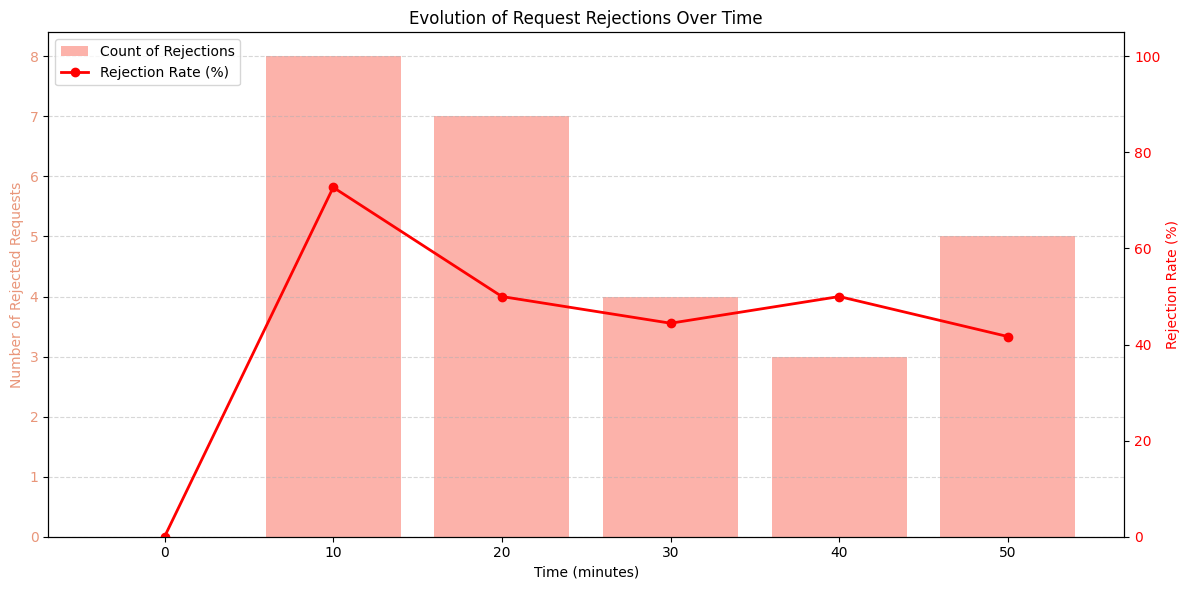

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract data from your history_stats dictionary
time_points = history_stats['time_step']
rejected = history_stats['reqs_rejected']
presented = history_stats['new_reqs_presented']

# 2. Calculate rejection rate (%) - handle division by zero with np.where
presented_arr = np.array(presented)
rejected_arr = np.array(rejected)
rejection_rate = np.divide(rejected_arr, presented_arr, out=np.zeros_like(rejected_arr, dtype=float), where=presented_arr!=0) * 100

# 3. Create the Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Number of Rejections as Bars
ax1.bar(time_points, rejected, color='salmon', alpha=0.6, label='Count of Rejections', width=8)
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('Number of Rejected Requests', color='darksalmon')
ax1.tick_params(axis='y', labelcolor='darksalmon')

# Create a second y-axis for the percentage
ax2 = ax1.twinx()
ax2.plot(time_points, rejection_rate, color='red', marker='o', linewidth=2, label='Rejection Rate (%)')
ax2.set_ylabel('Rejection Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105) # Percentage stays between 0-100

plt.title('Evolution of Request Rejections Over Time')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("rejection_evolution_only.png")
plt.show()

In [ ]:
# Convert the stats dictionary to a DataFrame
# This handles lists of different lengths by aligning them on the index
df_stats = pd.DataFrame.from_dict(history_stats, orient='index').transpose()

# Save to CSV
df_stats.to_csv("Maps/simulation_stats.csv", index=False)
print("Simulation statistics saved successfully.")

# Flatten the nested route history
flattened_routes = []

for bus_id, intervals in history_routes.items():
    for interval_data in intervals:
        t_val = interval_data['interval']
        for stop_idx, stop in enumerate(interval_data['route']):
            flattened_routes.append({
                'bus_id': bus_id,
                'simulation_time': t_val,
                'stop_sequence': stop_idx,
                'logical_node': stop['logical_node'],
                'physical_location': stop['location'],
                'arrival_time': stop['arrival_time']
            })

# Convert to DataFrame
df_routes = pd.DataFrame(flattened_routes)

# Save to CSV
df_routes.to_csv("Maps/vehicle_routes.csv", index=False)
print("Detailed routes saved to 'Maps/vehicle_routes.csv'.")

Simulation statistics saved successfully.
Detailed routes saved to 'Maps/vehicle_routes.csv'.
